# 06_ML_skater_expected_value_model.ipynb

# Data
We have data downloaded from the 2014/2015 - 2024/2025 season.

## Input data

The input data will only come from regular season games. 

For columns of the feature matrix, stats should be computed on a per game basis (e.g. goals per game, assists per game, time on ice per game, etc.).

## Target variable

The target variable will be the value per game.

According to the fantasy hockey league rules, a skater's value $v$ per game is calculated as 
$$
v = (2*G + A) / GP
$$
where $G$, $A$, and $GP$ are a skater's goals, assists and games played in the playoffs.

## Test dataset
We want to keep the 2024/2025 season as our test data, not to be used in model development.

## Design Considerations

### Players who did not make the playoffs in a given season
Since we are trying to answer the question: How valuable is player X given they made the playoffs this season, we can safely drop any players in a season who did not play in the playoffs in the corresponding season. This can be accomplished using an inner join per season.  


### Time series aspect
We are attempting to forecast future playoff predictions so we should not simply lump all the data into one table regardless of season. A random split for train/test data would be misleading because of things like player age, team strength, etc.

Instead, we should for example if trying to predict the 2023-2024 season playoffs, we should train on all data up to and including the 2022-2023 season and leave the 2023-2024 regular season data as validation.

This strategy could allow for a rolling cross-validation type of approach. That is, if we are predicting for season $Y$, train on data from years $ \leq Y-1$.

This way we stay true to the core idea of using historical data to predict the next season's playoff information.

Some pseudocode




```
for i in range(min_train_seasons, len(seasons)): # need at least min_train_seasons to train
    train_df = df with idx -> seasons[:i]
    val_df = df with idx -> seasons[i]

    get X_train, y_train, X_val, y_val

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    metrics = evaluate(y_val, y_pred)

```

### Team dependent features
In the data, we have many players who played for more than one team in the regular season (but not the case for playoffs because of league trading restrictions). However, we only have their player stats for the entire season and not per team. So in general, we should drop any team-related features.



# EDA
Let's look at the data for one season

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nhl_pool.config import PROCESSED_DIR

season = "20232024"

skaters_regular = pd.read_csv(PROCESSED_DIR / season / "regular" / "skaters.csv")

skaters_regular.head()

,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,goals,assists,...,powerPlayGoals,shorthandedGoals,gameWinningGoals,overtimeGoals,shots,shootingPctg,avgTimeOnIcePerGame,avgShiftsPerGame,faceoffWinPctg,sourceFile
0,8473986,Alex,Killorn,ANA,20232024,2,L,63,18,18,...,5,0,5,1,145,0.124138,1123.9206,22.2698,0.358974,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
1,8474641,Adam,Henrique,ANA,20232024,2,C,60,18,24,...,5,2,3,0,111,0.162162,1055.4667,22.2333,0.529089,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
2,8475164,Jakob,Silfverberg,ANA,20232024,2,R,81,7,12,...,1,1,1,0,102,0.068627,783.0370,17.5679,0.340000,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
3,8475462,Radko,Gudas,ANA,20232024,2,D,66,6,12,...,0,0,0,0,88,0.068182,1170.2727,23.8788,0.000000,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
4,8475764,Cam,Fowler,ANA,20232024,2,D,81,5,34,...,2,0,0,0,109,0.045872,1465.3704,26.8519,0.000000,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...


## Columns
Let's investigate all the columns available to us, and some preliminary thoughts on what to do with them


In [2]:
skater_cols = list(skaters_regular.columns)
skater_cols

['playerId',
 'firstName',
 'lastName',
 'teamAbbrev',
 'season',
 'seasonType',
 'positionCode',
 'gamesPlayed',
 'goals',
 'assists',
 'points',
 'plusMinus',
 'penaltyMinutes',
 'powerPlayGoals',
 'shorthandedGoals',
 'gameWinningGoals',
 'overtimeGoals',
 'shots',
 'shootingPctg',
 'avgTimeOnIcePerGame',
 'avgShiftsPerGame',
 'faceoffWinPctg',
 'sourceFile']

| Column Name | Notes |
|------------|-------|
| **playerId** | DROP (use only for bookkeeping) |
| **firstName** | DROP |
| **lastName** | DROP |
| **teamAbbrev** | DROP |
| **season** | DROP BEFORE TRAINING (keep only to split based on time properly in CV) |
| **seasonType** | DROP (use only for joins) |
| **positionCode** | KEEP (one-hot encode) |
| **sourceFile** | DROP |
| **gamesPlayed** | KEEP |
| **goals** | KEEP (turn into a rate) |
| **assists** | KEEP (turn into a rate) |
| **points** | KEEP (turn into a rate) |
| **plusMinus** | KEEP |
| **penaltyMinutes** | KEEP (turn into a rate) |
| **powerPlayGoals** | KEEP (turn into a rate) |
| **shorthandedGolas** | KEEP (turn into a rate) |
| **overtimeGoals** | KEEP (turn into a rate) |
| **shots** | KEEP (turn into a rate) |
| **shootingPctg** | KEEP |
| **avgTimeOnIcePerGame** | KEEP |
| **avgShiftsPerGame** | KEEP |
| **faceoffWinPctg** | KEEP |


### Correlation

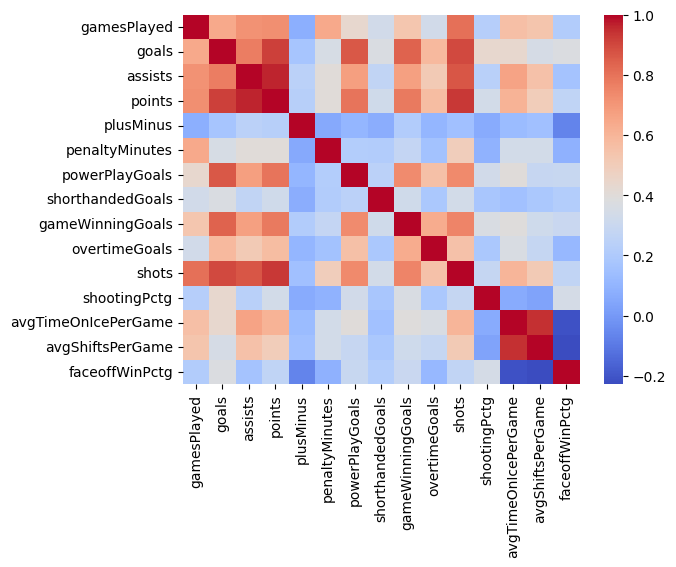

In [3]:
sns.heatmap(skaters_regular.drop(columns=["playerId", "season", "seasonType"]).corr(numeric_only=True), 
            annot=False, cmap="coolwarm")
plt.show()

We see the pretty obvious correlation between goals, assists, and points since points is just these two columns added together. 

We also observe that almost all of the count stats are correlated to gamesPlayed, as we would expect, re-emphasizing the importance of calculating the rates for our data.

# Load data

Let's load all the training data, calculate the rates, and then perform some more EDA

In [4]:
import numpy as np

def compute_target_variable(playoffs_df):
    '''
    Our target variable in the playoff data for skaters is:
    v = (2*goals + assists) / gamesPlayed
    
    Takes in the playoffs_df and adds target variable as another column
    '''
    playoffs_df = playoffs_df.copy()
    
    gp = playoffs_df["gamesPlayed"].astype(float)
    
    # Avoid divide by zero errors
    playoffs_df["playoffValuePerGame"] = np.where(
        gp > 0,
        (2.0 * playoffs_df["goals"] + playoffs_df["assists"]) / gp,
        np.nan
    )
    return playoffs_df
    

def load_one_season_raw_data(season_dir, player_type="skaters"):
    # Read data
    regular_df = pd.read_csv(season_dir / "regular" / f"{player_type}.csv")
    playoffs_df = pd.read_csv(season_dir / "playoffs" / f"{player_type}.csv")

    # Compute Target Variable
    playoffs_df = compute_target_variable(playoffs_df)

    
    # Join data on playerId. 
    # Inner join because we only want players who were in both the regular season and playoffs
    skaters = regular_df.merge(playoffs_df[["playerId", "playoffValuePerGame"]],
                            on="playerId",
                            how="inner")
    return skaters

def load_raw_data():
    season_dirs = [p for p in PROCESSED_DIR.iterdir() if p.is_dir()]
    season_dirs = season_dirs[:-1]   # exclude last season since that is the test data
    
    frames = []
    for d in season_dirs:
        frames.append(load_one_season_raw_data(d, player_type="skaters"))

    # Concatenate
    skaters = pd.concat(frames, ignore_index=True)
        
    return skaters


In [5]:
skaters = load_raw_data()
skaters.sort_values(by="playoffValuePerGame", ascending=False).head()

,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,goals,assists,...,shorthandedGoals,gameWinningGoals,overtimeGoals,shots,shootingPctg,avgTimeOnIcePerGame,avgShiftsPerGame,faceoffWinPctg,sourceFile,playoffValuePerGame
3529,8478402,Connor,McDavid,EDM,20192020,2,C,64,34,63,...,0,6,0,212,0.160000,1311.9375,21.1000,0.477600,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,3.500000
2806,8476461,Sean,Couturier,PHI,20172018,2,C,82,31,45,...,0,6,2,227,0.136600,1295.5000,26.5000,0.528500,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,2.800000
4368,8478402,Connor,McDavid,EDM,20212022,2,C,80,44,79,...,0,9,4,314,0.140000,1323.9750,21.9625,0.537285,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,2.687500
4714,8477934,Leon,Draisaitl,EDM,20222023,2,C,80,52,76,...,1,11,1,247,0.210526,1304.0375,22.7125,0.548980,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,2.583333
2834,8477404,Jake,Guentzel,PIT,20172018,2,C,82,22,26,...,0,1,0,171,0.128700,989.1707,21.9000,0.500000,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,2.583333


# EDA

Now let's do some more EDA now that we have all the data.

## Sanity checks

In [17]:
skaters.info()

<class 'pandas.DataFrame'>
RangeIndex: 5357 entries, 0 to 5356
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   playerId             5357 non-null   int64  
 1   firstName            5357 non-null   str    
 2   lastName             5357 non-null   str    
 3   teamAbbrev           5357 non-null   str    
 4   season               5357 non-null   int64  
 5   seasonType           5357 non-null   int64  
 6   positionCode         5357 non-null   str    
 7   gamesPlayed          5357 non-null   int64  
 8   goals                5357 non-null   int64  
 9   assists              5357 non-null   int64  
 10  points               5357 non-null   int64  
 11  plusMinus            5357 non-null   int64  
 12  penaltyMinutes       5357 non-null   int64  
 13  powerPlayGoals       5357 non-null   int64  
 14  shorthandedGoals     5357 non-null   int64  
 15  gameWinningGoals     5357 non-null   int64  
 16 

All columns are non-null for all entries.

In [23]:
skaters[skaters.isnull().any(axis=1)]

,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,goals,assists,...,shorthandedGoals,gameWinningGoals,overtimeGoals,shots,shootingPctg,avgTimeOnIcePerGame,avgShiftsPerGame,faceoffWinPctg,sourceFile,playoffValuePerGame


No empty rows

## Target variable

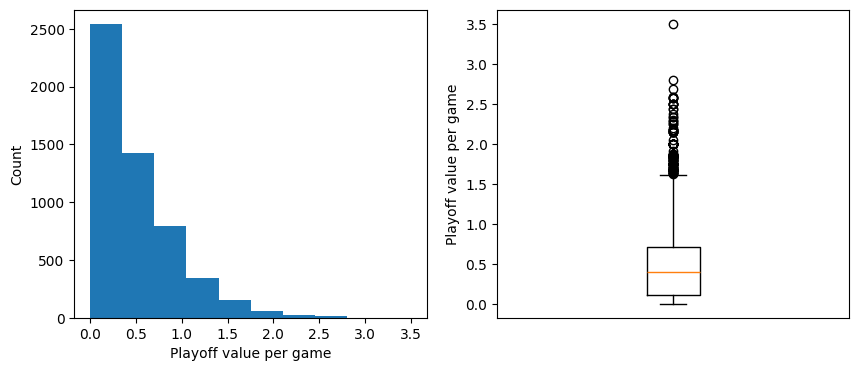

In [14]:
y = skaters["playoffValuePerGame"]
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

ax[0].hist(y)
ax[0].set_xlabel("Playoff value per game")
ax[0].set_ylabel("Count")

ax[1].boxplot(y)
ax[1].set_xticks([])
ax[1].set_ylabel("Playoff value per game")



plt.show()

We can see that the majority of the dataset have a pretty low value per game in the playoffs (right-skewed). This could make sense since points are a relatively rare per game activity amongst all the players. This would be especially true in the playoffs where players play less games and therefore less chances to score points.

For our model we really want to properly predict high value players since this will maximize our points, so modelling choices which prioritize performance of the upper tail might be more beneficial than global MSE for example.

## Playoff value per position

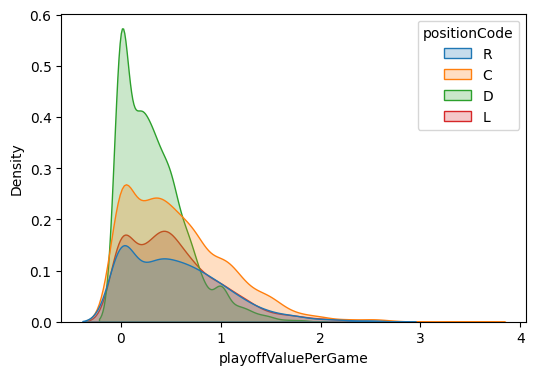

In [48]:
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(skaters, x="playoffValuePerGame", hue="positionCode", fill=True, ax=ax)
plt.show()

As expected, defencemen generate less points than forwards.

## Distribution of positions

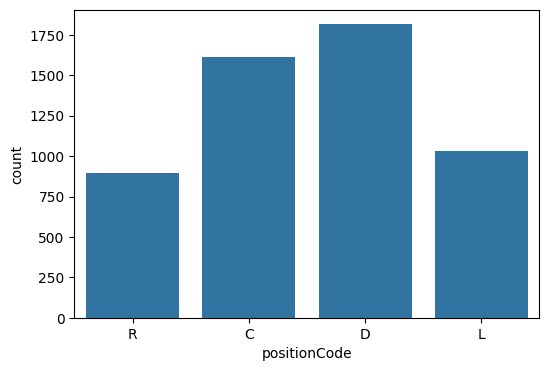

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(skaters, x="positionCode", ax=ax)
plt.show()

Distribution between forwards and defence seems flat enough, not a considerable imbalance between the two,

## gamesPlayed

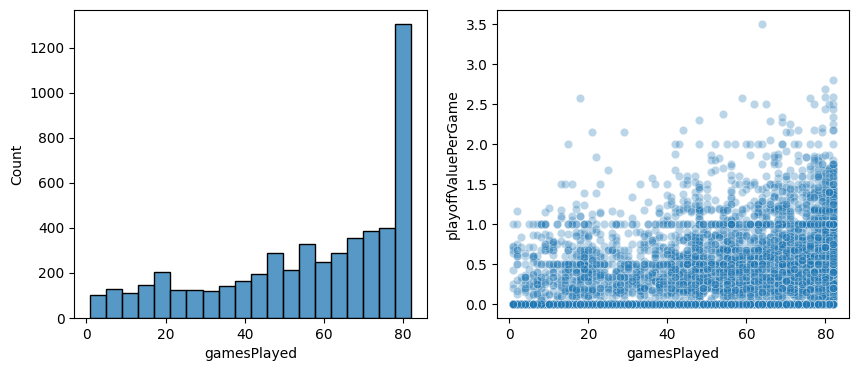

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
sns.histplot(skaters, x="gamesPlayed", ax=ax[0])

sns.scatterplot(data=skaters, x="gamesPlayed", y="playoffValuePerGame", ax=ax[1], alpha=0.3)

plt.show()

Players largely play the entire season (max 82 games).

There seems to be a very slight positive relationship between number of regular season games played and playoff value per game, but it is very noisy.

## Raw counts vs rates

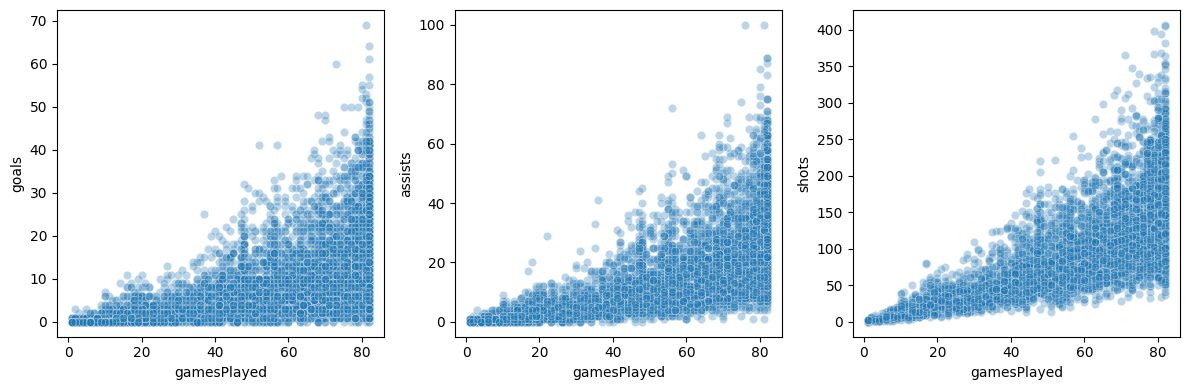

In [45]:
fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.scatterplot(data=skaters, x="gamesPlayed", y="goals", ax=ax[0], alpha=0.3)

sns.scatterplot(data=skaters, x="gamesPlayed", y="assists", ax=ax[1], alpha=0.3)

sns.scatterplot(data=skaters, x="gamesPlayed", y="shots", ax=ax[2], alpha=0.3)

fig.tight_layout()
plt.show()

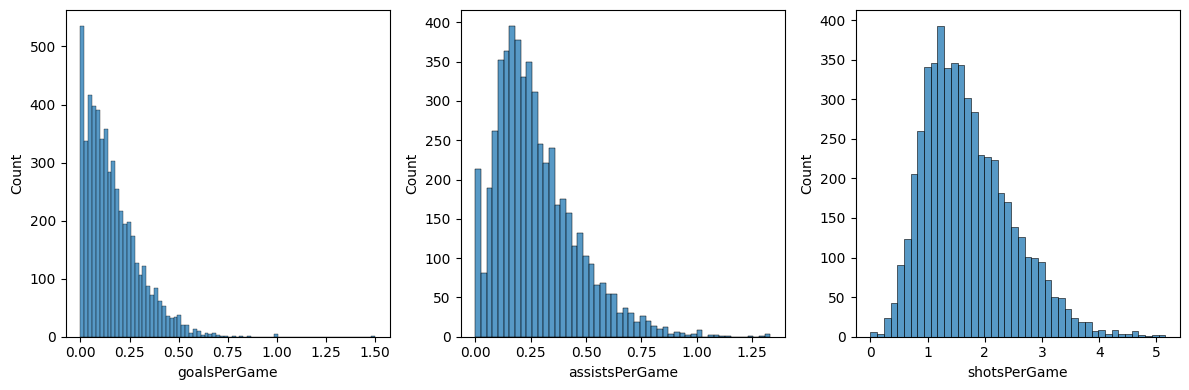

In [ ]:
skaters["goalsPerGame"] = skaters["goals"] / skaters["gamesPlayed"]
skaters["assistsPerGame"] = skaters["assists"] / skaters["gamesPlayed"]
skaters["pointsPerGame"] = skaters["points"] / skaters["gamesPlayed"]
skaters["shotsPerGame"] = skaters["shots"] / skaters["gamesPlayed"]


fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.histplot(data=skaters, x="goalsPerGame", ax=ax[0])
sns.histplot(data=skaters, x="assistsPerGame", ax=ax[1])
sns.histplot(data=skaters, x="shotsPerGame", ax=ax[2])

fig.tight_layout()
plt.show()

The histograms of a few of per game-based stats show a right skew, indicating that features should be regularised.

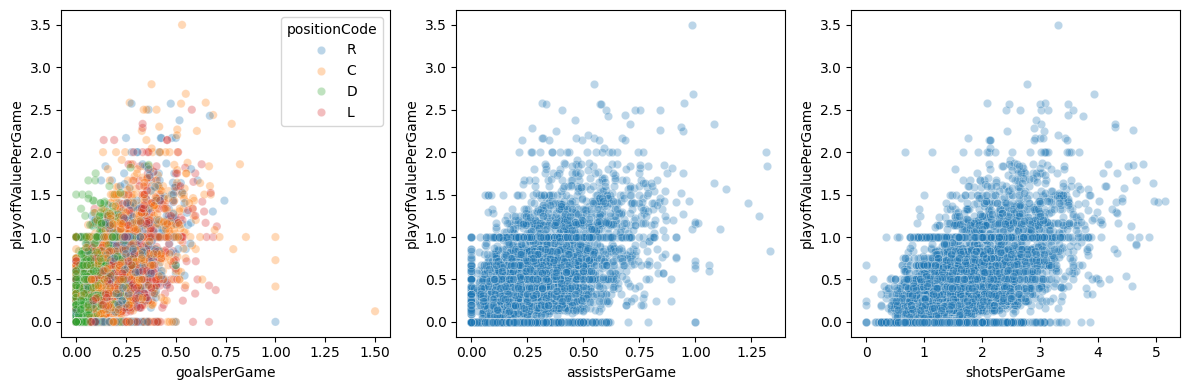

In [47]:
fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.scatterplot(data=skaters, x="goalsPerGame", y="playoffValuePerGame", ax=ax[0], alpha=0.3, hue="positionCode")

sns.scatterplot(data=skaters, x="assistsPerGame", y="playoffValuePerGame", ax=ax[1], alpha=0.3)

sns.scatterplot(data=skaters, x="shotsPerGame", y="playoffValuePerGame", ax=ax[2], alpha=0.3)

fig.tight_layout()
plt.show()

There is a increasing relationship with our per game stats and playoff value, but it is quite noisy.

## Time on ice

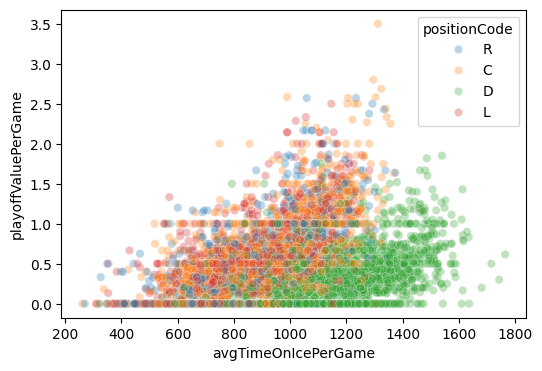

In [44]:
fig,ax = plt.subplots(figsize=(6,4))
sns.scatterplot(skaters, x="avgTimeOnIcePerGame", y="playoffValuePerGame", ax=ax, alpha=0.3, hue="positionCode")
plt.show()

We see that defencemen in general have more ice time that forwards. We also observe that higher scoring players typically align with more ice time being played.

The scale of this feature is different than others, we should normalize features in general.

## Correlation
Let's look at the correlation between the rate statistics

In [62]:
def generate_rate_stats(skaters):
    
    # init blank df
    out = pd.DataFrame()
    
    # Columns to turn into a rate
    rate_cols = ["goals", "assists", "points", "penaltyMinutes", "powerPlayGoals", "shorthandedGoals", "gameWinningGoals", "overtimeGoals", "shots"]
    all_cols = list(skaters.columns)
    other_cols = [a for a in all_cols if a not in rate_cols]
    
    out[other_cols] = skaters[other_cols]
    
    gp = out["gamesPlayed"]
    
    for c in rate_cols:
        out[f"{c}PerGame"] = skaters[c] / gp
    
    return out

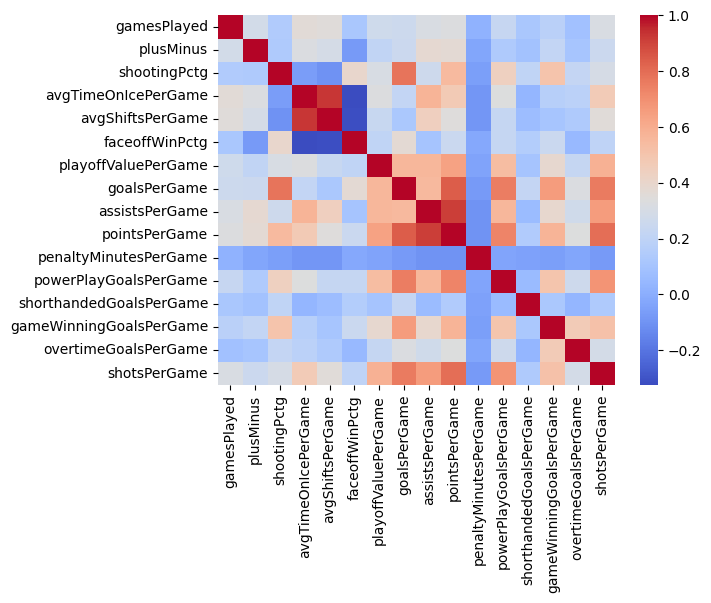

In [88]:
skaters = load_raw_data()
skaters = generate_rate_stats(skaters)

sns.heatmap(skaters.drop(columns=["playerId", "season", "seasonType"]).corr(numeric_only=True), 
            annot=False, cmap="coolwarm")
plt.show()

There is some correlation between features, but we do not have a large feature space so we may not want to do PCA reduction.

## Pairplot

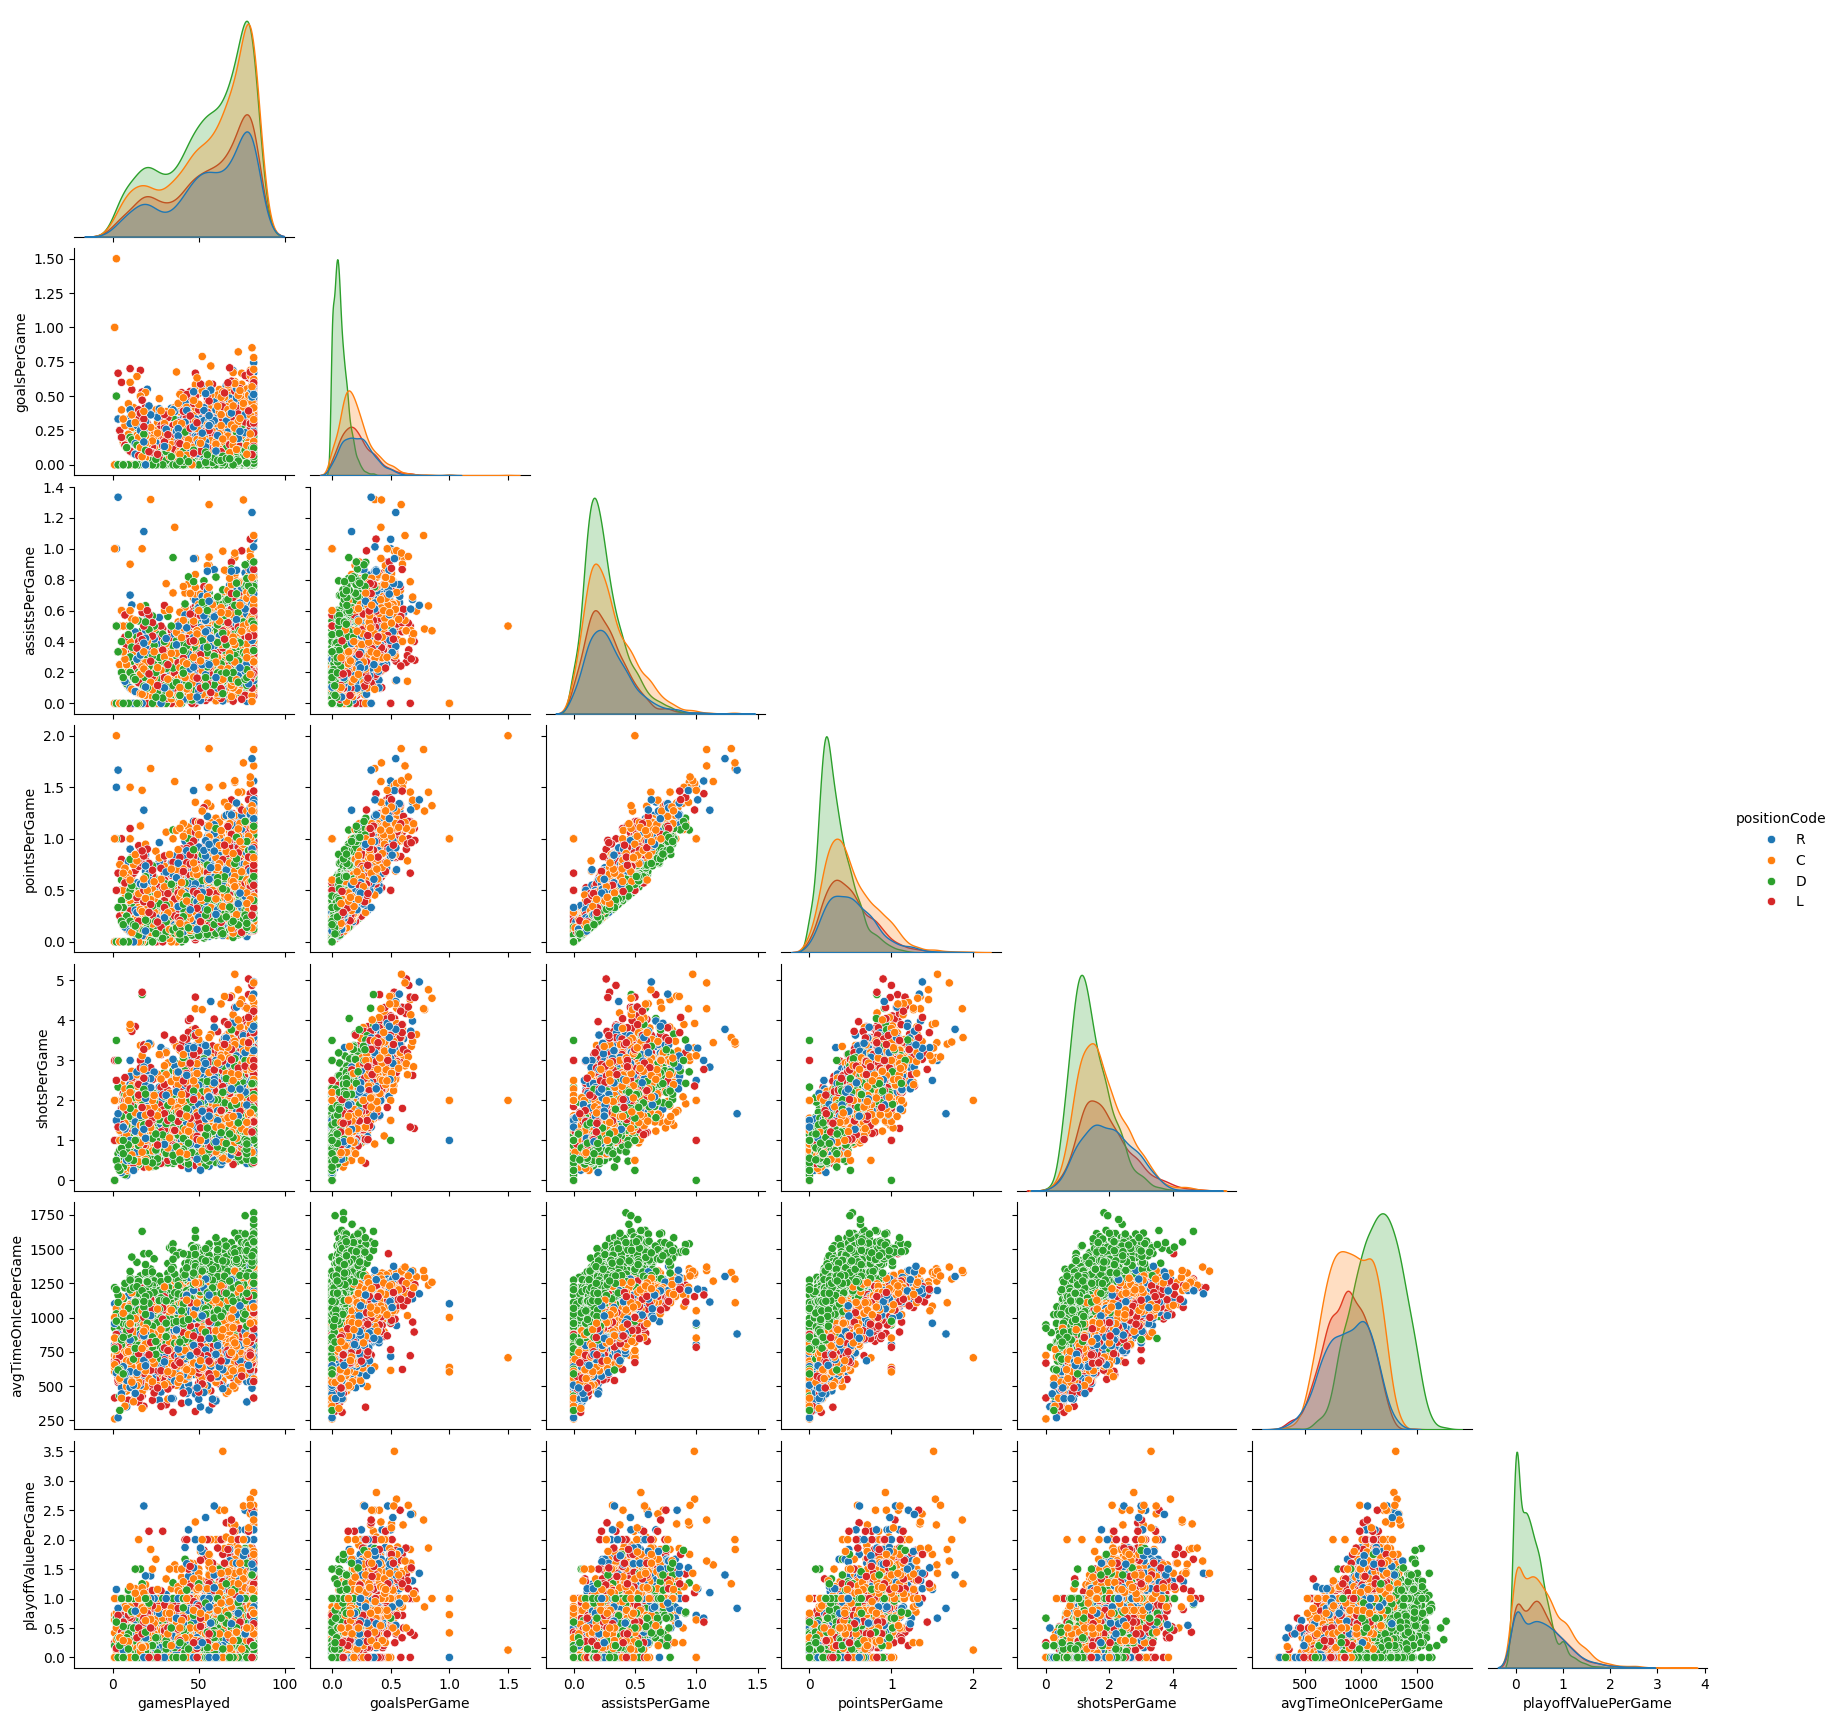

In [76]:
sns.pairplot(data=skaters, 
             vars=["gamesPlayed", "goalsPerGame", "assistsPerGame", 
                   "pointsPerGame", "shotsPerGame","avgTimeOnIcePerGame", "playoffValuePerGame"], 
             corner=True, hue="positionCode")
plt.show()

We do see a noticable difference in stats for defencemen vs forwards. Across the stats, there does seem to be a positive relationship with the stats to playoff value.

## EDA Takeaways

The signal between input variable to playoff value is quite noisy, meaning this will be a challenging task.

# Per Game Rate Transformer

We want to standardize how we are importing data and calculating rates.


In [82]:
from sklearn.base import BaseEstimator, TransformerMixin

class PerGameRateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, rate_cols, gp_col="gamesPlayed", drop_raw=True):
        self.rate_cols = rate_cols
        self.gp_col = gp_col
        self.drop_raw = drop_raw
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        gp = X[self.gp_col].astype(float)
        gp_safe = np.where(gp > 0, gp, np.nan)
        
        for c in self.rate_cols:
            X[f"{c}PerGame"] = X[c].astype(float) / gp_safe
        
        X = X.replace([-np.inf, np.inf], np.nan)
        
        if self.drop_raw:
            X = X.drop(columns=self.rate_cols)
        
        return X

In [90]:
RATE_COLS = [
    "goals",
    "assists",
    "points",
    "penaltyMinutes",
    "powerPlayGoals",
    "shortHandedGoals",
    "overtimeGoals",
    "shots",
]
rate_cols = ["goals", "assists", "points", "penaltyMinutes", "powerPlayGoals", "shorthandedGoals", "gameWinningGoals", "overtimeGoals", "shots"]
    

GP_COL = "gamesPlayed"

skaters = load_raw_data()
X = skaters.drop(columns=["playoffValuePerGame"])
t = PerGameRateTransformer(rate_cols=rate_cols)
X = t.transform(X)

X.head()

,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,plusMinus,shootingPctg,...,sourceFile,goalsPerGame,assistsPerGame,pointsPerGame,penaltyMinutesPerGame,powerPlayGoalsPerGame,shorthandedGoalsPerGame,gameWinningGoalsPerGame,overtimeGoalsPerGame,shotsPerGame
0,8457981,Teemu,Selanne,ANA,20102011,2,R,73,6,0.1455,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.424658,0.671233,1.095890,0.671233,0.219178,0.0,0.068493,0.0,2.917808
1,8459442,Saku,Koivu,ANA,20102011,2,C,75,-8,0.1442,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.200000,0.400000,0.600000,0.480000,0.053333,0.0,0.040000,0.0,1.386667
2,8459587,Todd,Marchant,ANA,20102011,2,C,79,-18,0.0159,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.012658,0.088608,0.101266,0.329114,0.000000,0.0,0.000000,0.0,0.797468
3,8465042,Toni,Lydman,ANA,20102011,2,D,78,32,0.0303,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.038462,0.282051,0.320513,0.538462,0.000000,0.0,0.000000,0.0,1.269231
4,8466144,Paul,Mara,ANA,20102011,2,D,33,-1,0.0294,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.030303,0.030303,0.060606,1.212121,0.000000,0.0,0.030303,0.0,1.030303


# Baseline
We need a benchmark for the models we are developing to make sure they are actually any good. 

Use the 2024-2025 season as the test data, the rest as training data.


## Load training data

In [97]:
skaters_train = load_raw_data()

# Split into feature matrix and target variable
X_train = skaters_train.drop(columns=["playoffValuePerGame"])
y_train = skaters_train["playoffValuePerGame"]

# Transform the rates
t = PerGameRateTransformer(rate_cols=rate_cols)

X_train = t.transform(X_train)
X_train.head()


,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,plusMinus,shootingPctg,...,sourceFile,goalsPerGame,assistsPerGame,pointsPerGame,penaltyMinutesPerGame,powerPlayGoalsPerGame,shorthandedGoalsPerGame,gameWinningGoalsPerGame,overtimeGoalsPerGame,shotsPerGame
0,8457981,Teemu,Selanne,ANA,20102011,2,R,73,6,0.1455,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.424658,0.671233,1.095890,0.671233,0.219178,0.0,0.068493,0.0,2.917808
1,8459442,Saku,Koivu,ANA,20102011,2,C,75,-8,0.1442,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.200000,0.400000,0.600000,0.480000,0.053333,0.0,0.040000,0.0,1.386667
2,8459587,Todd,Marchant,ANA,20102011,2,C,79,-18,0.0159,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.012658,0.088608,0.101266,0.329114,0.000000,0.0,0.000000,0.0,0.797468
3,8465042,Toni,Lydman,ANA,20102011,2,D,78,32,0.0303,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.038462,0.282051,0.320513,0.538462,0.000000,0.0,0.000000,0.0,1.269231
4,8466144,Paul,Mara,ANA,20102011,2,D,33,-1,0.0294,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.030303,0.030303,0.060606,1.212121,0.000000,0.0,0.030303,0.0,1.030303


## Load testing data

In [ ]:
test_season_dir = PROCESSED_DIR / "20242025"
skaters_test = load_one_season_raw_data(test_season_dir)

# Split into feature matrix and target variable
X_test = skaters_test.drop(columns=["playoffValuePerGame"])
y_test = skaters_test["playoffValuePerGame"]

# Transform the rates
t = PerGameRateTransformer(rate_cols=rate_cols)

X_test = t.transform(X_test)
X_test.head()

,playerId,firstName,lastName,teamAbbrev,season,seasonType,positionCode,gamesPlayed,plusMinus,shootingPctg,...,sourceFile,goalsPerGame,assistsPerGame,pointsPerGame,penaltyMinutesPerGame,powerPlayGoalsPerGame,shorthandedGoalsPerGame,gameWinningGoalsPerGame,overtimeGoalsPerGame,shotsPerGame
0,8475208,Brian,Dumoulin,ANA,20242025,2,D,61,2,0.035088,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.032787,0.229508,0.262295,0.163934,0.000000,0.000000,0.000000,0.000000,0.934426
1,8475764,Cam,Fowler,ANA,20242025,2,D,17,-7,0.000000,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.000000,0.235294,0.235294,0.352941,0.000000,0.000000,0.000000,0.000000,1.000000
2,8473419,Brad,Marchand,BOS,20242025,2,L,61,-8,0.120000,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.344262,0.426230,0.770492,1.016393,0.081967,0.000000,0.081967,0.032787,2.868852
3,8475745,Charlie,Coyle,BOS,20242025,2,C,64,-14,0.163043,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.234375,0.109375,0.343750,0.281250,0.046875,0.015625,0.031250,0.000000,1.437500
4,8478443,Brandon,Carlo,BOS,20242025,2,D,63,2,0.015625,...,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,0.015873,0.126984,0.142857,0.380952,0.000000,0.000000,0.000000,0.000000,1.015873


In [123]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

## Baseline 0: Mean Value
What if we just predict every player's playoff value to be the mean of the training data.

If our models do not perform better than this, then something is truly wrong.

In [ ]:

y_pred = np.full_like(y_test, y_train.mean(), dtype=float)

print("Baseline 0: Mean Value")
print(f"Spearman Correlation: N/A")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Baseline 0: Mean Value
Spearman Correlation: N/A
MAE: 0.3889766605265253
R2 Score: -0.023526018765003265


Spearman correlation does not work as a metric here because the values of y_pred are constant.

## Baseline 1: Direct goal and assist per game calculation

We can simply use the regular season goals and assists per game and calculate their regular season value per game and use this as their predicted playoff value per game. 


In [ ]:
y_pred = 2*X_test["goalsPerGame"] + X_test["assistsPerGame"]

print("Baseline 1: GPG and APG Regular Season")
print(f"Spearman Correlation: {spearmanr(y_test, y_pred).correlation}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Baseline 1: GPG and APG Regular Season
Spearman Correlation: 0.6492574647330366
MAE: 0.2997317061615514
R2 Score: 0.39945808597421717


We see meaningful improvements to the MAE and R2 metrics. The R2 here indicates that 40% of the variance has been explained.

A Spearman correlation coefficient of 0.65 is quite good for such a simple assumption, using only two features, and no training. This indicates that our ranking of data is pretty good.



## Baseline 2: GPG and APG with GP shrinkage
We might be able to enhance our Baseline 1 slightly by accounting that some players in the regular season played few games. If a player played less than a certain amount of games, we can replace their GPG and APG metrics with the league average in the training data.




In [117]:
min_GP = 10
mask = X_test["gamesPlayed"] < min_GP

y_pred = 2*X_test["goalsPerGame"] + X_test["assistsPerGame"]
y_pred[mask] = y_train.mean()

print("Baseline 2: GPG and APG Regular Season")
print(f"Spearman Correlation: {spearmanr(y_test, y_pred).correlation}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Baseline 2: GPG and APG Regular Season
Spearman Correlation: 0.6354705177572327
MAE: 0.3031634965126072
R2 Score: 0.39494554633117374


Interestingly, this performed slightly worse in all metrics compared to Baseline 1.

## Baseline 3: Minimal linear regression

We will implement a minimal linear regression model and use it as a baseline.

Let's just use some of the numerical columns (so we don't need to do any encoding right now).

In [122]:
from sklearn.linear_model import LinearRegression

cols_drop = ['playerId', 'firstName', 'lastName', 'teamAbbrev', 'season',
       'seasonType', 'positionCode', 'sourceFile']

lin = LinearRegression()
lin.fit(X_train.drop(columns=cols_drop), y_train)

y_pred = lin.predict(X_test.drop(columns=cols_drop))

print("Baseline 3: Minimal Linear Regression")
print(f"Spearman Correlation: {spearmanr(y_test, y_pred).correlation}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

Baseline 3: Minimal Linear Regression
Spearman Correlation: 0.6788213885850911
MAE: 0.27558631957915947
R2 Score: 0.479903682862162


This is our best performing baseline thus far, with improvements to all of our metrics.

Any further models we develop should be improvements from this baseline.

# Model Development

## Pre-processing